# Mini project

this project show the Salary regarding for years experience 
***************************
so in this project we will aprove each part on linear regression and how polynomial regression make a good soloution

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
#%%
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline


Read the dataset 

In [3]:
data = pd.read_csv(r"Salary_Data.csv") # real
data.tail()
# data.info()
# data.describe()


,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


display the distribution of dataset

<Figure size 300x300 with 0 Axes>

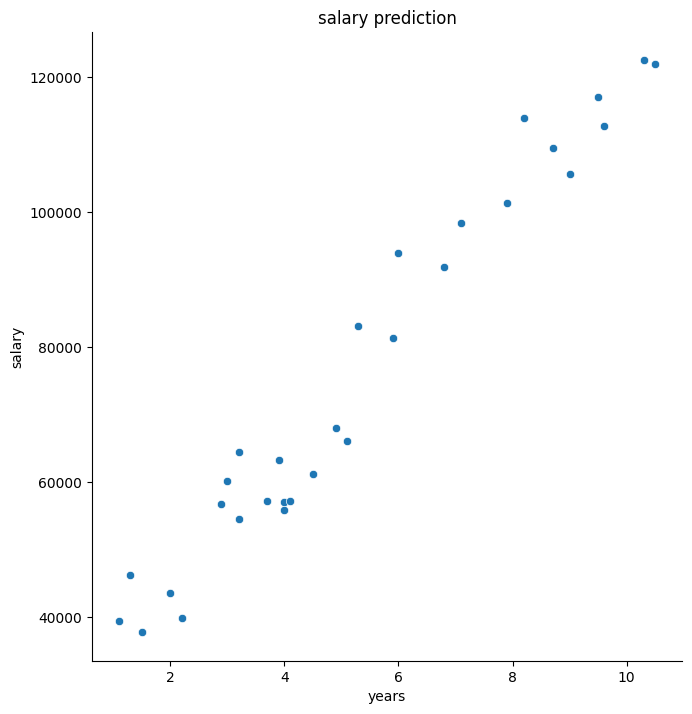

In [4]:
#%%
plt.figure(figsize=(3,3))
sns.pairplot(data,x_vars=["YearsExperience"],y_vars=["Salary"],size=7,kind="scatter")
plt.xlabel("years")
plt.ylabel("salary")
plt.title("salary prediction")
plt.show()


preprocessing steps to splite the dataset for coloumn represent X and Y 

In [5]:
#%%
# cooking the data 
X = data.iloc[:,:-1]
y = data.iloc[:,1]

X_train , X_test , y_train , y_test = train_test_split(X,y,train_size=0.8,random_state = 10)

In [6]:

my_model = LinearRegression()
my_model.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


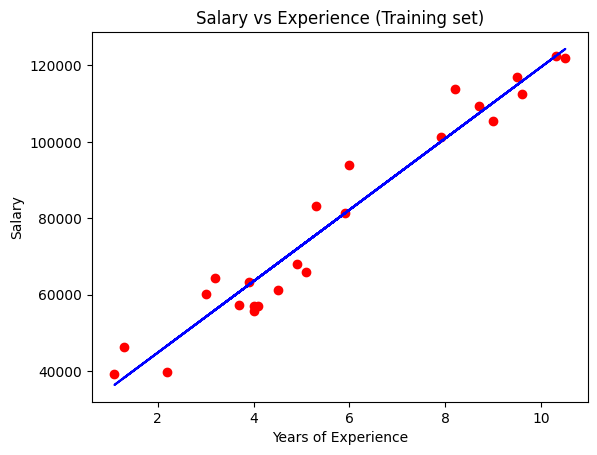

In [7]:
#%%
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, my_model.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()



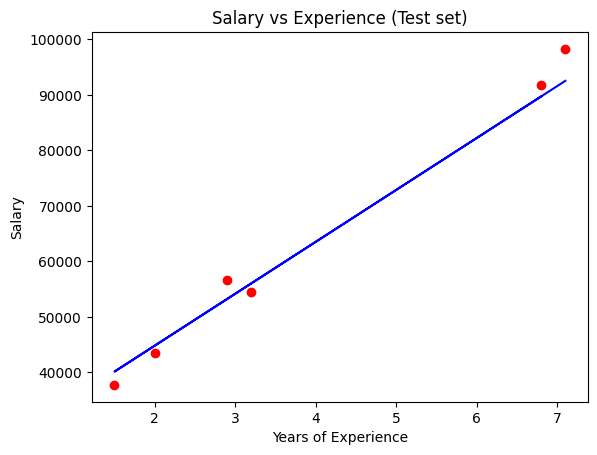

In [8]:
#%%
y_pred = my_model.predict(X_test)
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_test, y_pred, color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()
#%%


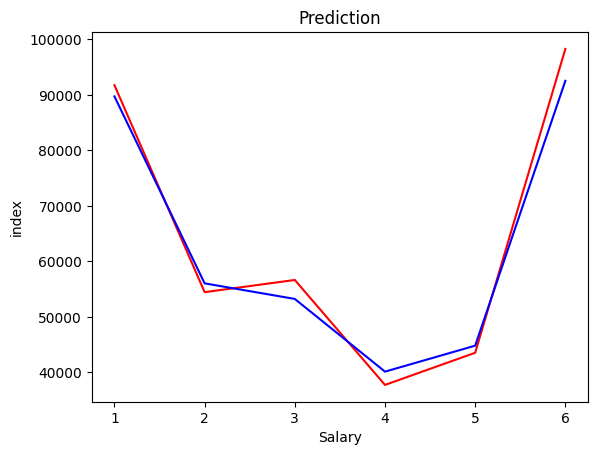

In [9]:
# Plotting the actual and predicted values

c = [i for i in range(1,len(y_test)+1)]
plt.plot(c,y_test,color='r',linestyle='-')
plt.plot(c,y_pred,color='b',linestyle='-')
plt.xlabel('Salary')
plt.ylabel('index')
plt.title('Prediction')
plt.show()
#%%



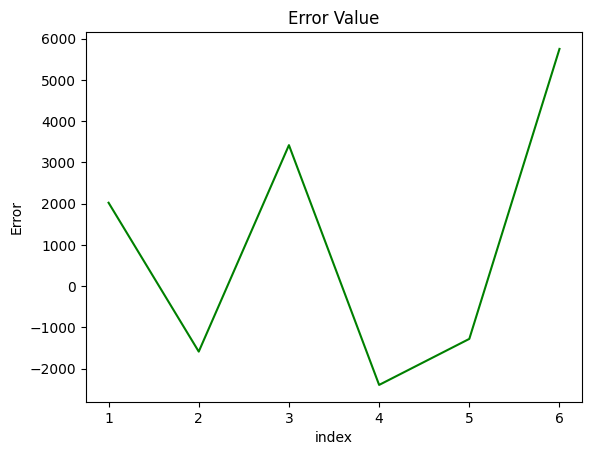

In [10]:
# plotting the error
c = [i for i in range(1,len(y_test)+1)]
plt.plot(c,y_test-y_pred,color='green',linestyle='-')
plt.xlabel('index')
plt.ylabel('Error')
plt.title('Error Value')
plt.show()
#%%


In [11]:
# calculate Mean square error
mse = mean_squared_error(y_test,y_pred)
# Calculate R square vale
rsq = r2_score(y_test,y_pred)
print('mean squared error :',mse)
print('r square :',rsq)
#%%
# Intecept and coeff of the line
print('Intercept of the model:',my_model.intercept_)
print('Coefficient of the line:',my_model.coef_)

y_hat = 9357 * 7 +  26089 
print(y_hat)

mean squared error : 9785570.138914317
r square : 0.9816423482070253
Intercept of the model: 26089.096632416724
Coefficient of the line: [9356.86299354]
91588


In [12]:
x=int(input("pls inter your years experience"))
y_hat = 9357 * x +  26089 
y_hat

213229

In [ ]:
import numpy as np

class LinearRegression_ahmed_salah:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # Initialize parameters
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.iterations):
            # linear formula: y = wx + b
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

In [14]:
# Example Usage:
model = LinearRegression_ahmed_salah(learning_rate=0.1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

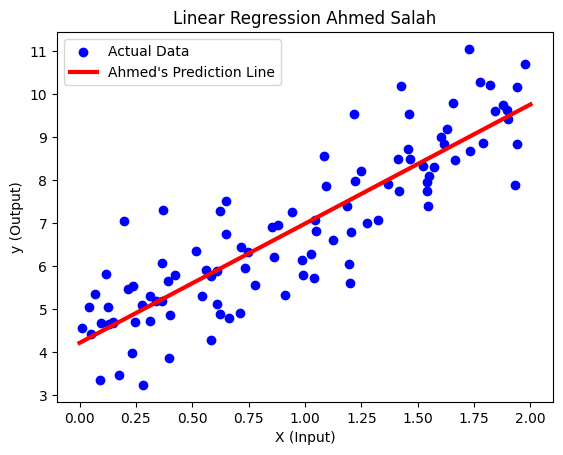

Model Weights: [2.77011342]
Model Bias: 4.21509612092742


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Generate Synthetic Data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise
y = y.flatten()

model = LinearRegression_ahmed_salah(learning_rate=0.1, iterations=1000)
model.fit(X, y)

# Make Predictions
X_new = np.array([[0], [2]])
y_predict = model.predict(X_new)

#Visualize the Results
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X_new, y_predict, color="red", linewidth=3, label="Ahmed's Prediction Line")
plt.xlabel("X (Input)")
plt.ylabel("y (Output)")
plt.legend()
plt.title("Linear Regression Ahmed Salah")
plt.show()

print(f"Model Weights: {model.weights}")
print(f"Model Bias: {model.bias}")